# New section

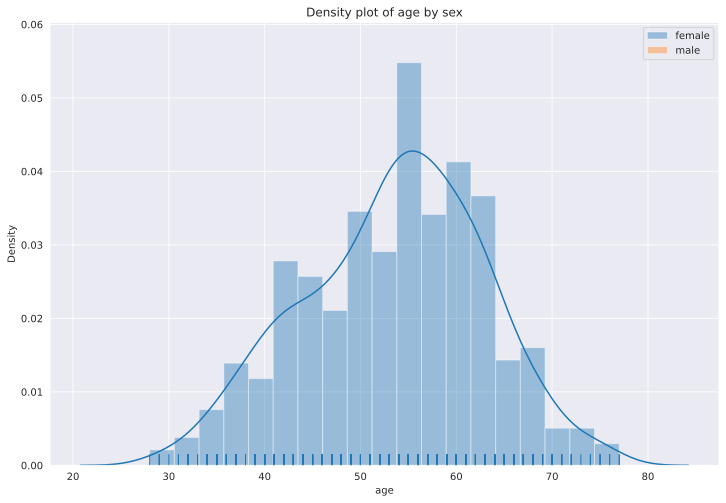

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.offline as py


import warnings
warnings.filterwarnings('ignore')

py.offline.init_notebook_mode(connected=True)
import plotly.graph_objs as go

%matplotlib inline
# Plot in SVG format since this format is more sharp and legible
%config InlineBackend.figure_format = 'svg'
path = 'heart_data.csv'
df = pd.read_csv(path)
df.head()
num_cont_feat = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
cat_feat = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
df['sex'] = df['sex'].apply(lambda x: 'male' if x == 1 else 'female')
df['exang'] = df['exang'].map({1: 'Yes', 0:'No'})
plt.rcParams['figure.figsize']= (12,8) # figure size
sns.set_style('darkgrid') # Style
sns.distplot(df[df['sex']=='female']['age'], rug=True, hist=True, label='female')
sns.distplot(df[df['sex']=='male']['age'], rug=True, hist=True, label='male')
plt.legend()
plt.title('Density plot of age by sex');

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

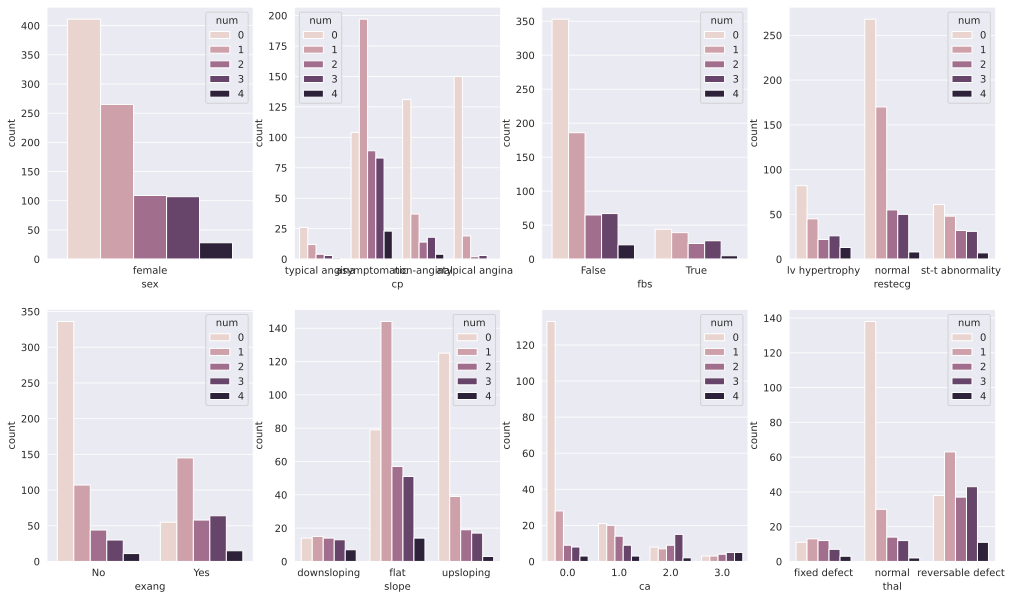

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.offline as py


import warnings
warnings.filterwarnings('ignore')

py.offline.init_notebook_mode(connected=True)
import plotly.graph_objs as go

%matplotlib inline
# Plot in SVG format since this format is more sharp and legible
%config InlineBackend.figure_format = 'svg'
path = 'heart_data.csv'
df = pd.read_csv(path)
num_cont_feat = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
cat_feat = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
df['sex'] = df['sex'].apply(lambda x: 'male' if x == 1 else 'female')
df['exang'] = df['exang'].map({1: 'Yes', 0:'No'})
plt.rcParams['figure.figsize']= (1,12) # figure size
sns.set_style('darkgrid') # Style
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(17,10))

for idx, feature in enumerate(cat_feat):
    ax = axes[int(idx/4), idx%4]
    if feature != 'target':
        sns.countplot(x=feature, hue='num', data=df, ax=ax)

In [8]:
print(df.columns)


Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')


In [5]:
from google.colab import files
uploaded = files.upload()

Saving heart_data.csv to heart_data.csv


In [6]:
import os
os.listdir()

['.config', 'heart_data.csv', 'sample_data']

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.offline as py


import warnings
warnings.filterwarnings('ignore')

py.offline.init_notebook_mode(connected=True)
import plotly.graph_objs as go

%matplotlib inline
# Plot in SVG format since this format is more sharp and legible
%config InlineBackend.figure_format = 'svg'
path = 'heart_data.csv'
df = pd.read_csv(path)
num_cont_feat = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
cat_feat = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
df['sex'] = df['sex'].map({'female': 0, 'male': 1})
df['exang'] = df['exang'].map({'No': 0, 'Yes': 1})
plt.rcParams['figure.figsize']= (1,12) # figure size
sns.set_style('darkgrid') # Style
plt.figure(figsize=(30,30))
sns.set_style('darkgrid')
sns.pairplot(df[num_cont_feat])


<Figure size 3000x3000 with 0 Axes>

# Clean Dataset and Split Training, Validation, and Test sets



In [15]:
# Load .csv
import pandas as pd
heart_data = pd.read_csv("/heart_data.csv")
heart_data.info()
heart_data.isnull().sum()
heart_data.head()

#  Remove duplicates
heart_data = heart_data.drop_duplicates()

# Fill missing numeric values
heart_data = heart_data.fillna(heart_data.median(numeric_only=True))

# Feature Engineering
# Transform continuous features
def engineer_features(df):
    df['chol_age_ratio'] = df['chol'] / df['age']
    df['maxHR_age_ratio'] = df['thalch'] / df['age']
    df['age_chol'] = df['age'] * df['chol']
    df['age_maxHR'] = df['age'] * df['thalch']
    df['age_group'] = pd.cut(df['age'], bins=[29,40,50,60,78], labels=[0,1,2,3])
    df['chol_level'] = pd.cut(df['chol'], bins=[100,200,240,600], labels=[0,1,2])
    return df

heart_data = engineer_features(heart_data)

def add_binary_risk_flags(df):
    df['high_bp'] = df['trestbps'].apply(lambda x: 1 if x > 140 else 0)
    df['high_chol'] = df['chol'].apply(lambda x: 1 if x > 240 else 0)
    df['low_maxHR'] = df['thalch'].apply(lambda x: 1 if x < 120 else 0)
    df['high_oldpeak'] = df['oldpeak'].apply(lambda x: 1 if x > 2 else 0)
    df['older_age'] = df['age'].apply(lambda x: 1 if x > 55 else 0)
    return df

# Apply to the whole dataset
heart_data = add_binary_risk_flags(heart_data)

# Create binary target column from 'num' so that:
# 0 = no heart disease, 1 = any heart disease
heart_data['target'] = heart_data['num'].apply(lambda x: 0 if x == 0 else 1)

# Detect categorical columns (exclude 'num' and 'target')
categorical_cols = heart_data.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in ['num', 'target']]

# One-hot encode categorical columns (Converts categorical into binary so that the model can understand)
heart_data = pd.get_dummies(heart_data, columns=categorical_cols, drop_first=True)

# Split features and target
x = heart_data.drop(['num', 'target'], axis=1)
y = heart_data['target']

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split into train+val and test
# 85% training and 15% testing
x_train_val, x_test, y_train_val, y_test = train_test_split(
    x, y, test_size=0.15, random_state=42, stratify=y
)

# Split train+val into train and validation
# 18% (of 85%, so 15% of total) validation and 70% training
x_train, x_val, y_train, y_val = train_test_split(
    x_train_val, y_train_val, test_size=0.18, random_state=42, stratify=y_train_val
)

# Scale numeric features
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
x_val = scaler.transform(x_val)

print("Cleaned Dataset:")
print("Training:", x_train.shape, y_train.shape)
print("Testing:", x_test.shape, y_test.shape)
print("Validation:", x_val.shape, y_val.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
Cleaned Dataset:
Training: (641, 36) (641,)
Testing: (138, 36) (138,)
Validation: (141, 36) (141,)


# Random Forest Learning Model and Validate the Model

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize the model
model = RandomForestClassifier(
    n_estimators=1000,
    max_depth=10,
    class_weight={0: 1.5, 1: 1},  # increase weight for healthy patients
    random_state=42
)
# 42 for consistency
# 1000 ensures convergence

# Train the model on the training data
model.fit(x_train, y_train)

# Validate the accuracy of the prediction before test set
y_val_pred = model.predict(x_val)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))

# Predict on the test set
y_pred = model.predict(x_test)

# Accuracy of correct predictions on the test set
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

# Confusion matrix
# Shows:
# [[True N, False P]
# [False N, True P]]
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Detailed classification report
print("Classification Report:\n", classification_report(y_test, y_pred))
# Precision = How many predicted actually had
# Recall = How many that had, did get predicted
# F1-Score = Balance of Precision and Recall into 1 number
# Support = Number of samples

Validation Accuracy: 0.8652482269503546
Test Accuracy: 0.8840579710144928
Confusion Matrix:
 [[49 13]
 [ 3 73]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.79      0.86        62
           1       0.85      0.96      0.90        76

    accuracy                           0.88       138
   macro avg       0.90      0.88      0.88       138
weighted avg       0.89      0.88      0.88       138



# **Accuracy, Precision, and Recall Review**

**[TN FP]**

**[FN TP]**

---



**0 = Not Diseased**

**1 = Diseased**

**Precision = % of Disease predictions that were correct (Correct Diagnosis of Disease)**

**Recall = % of Diseased that were correctly predicted as such (% of the Diseased patients that the model predicted)**



---

**Most important is the TP (True Positive) because this is the % of the people with heart disease that the model correctly diagnosed.**

**True Positive: 96%**

**Accuracy : 88%**